# 075. Poetry text generation - seq2seq Transfer Learning

## Korean word2vec


- 두개의 model 로 구성  
    - model1 : many-to-many RNN model for fine tuning
    - model2 : many-to-many RNN model for sequence-to-sequence prediction
    

- Model 1 에서 Embedding Layer 를 훈련 시키고, 훈련시킨 Embedding 을 Model 2 에서 Text Generation 에 사용  


- Model 1 은 Glove.6B pre-trained weight 를 초기값으로 사용하고, single LSTM 으로 fine tuning  


- Model 2 는 Model 1 에서 train 된 Embedding + LSTM 의 이전 timestep prediction 의 hidden state 와 cell state 를 초기값으로 사용


- Model 2 에서는 idx = np.random.choice(len(probs), p=probs) $\rightarrow$ 사후 확률분포 (posterios probability distribution) 에 의해 next word sampling

<img src="seq2seq.png" width="600"/>

In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, Input, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam

In [0]:
# some configuration
MAX_VOCAB_SIZE = 3000
EMBEDDING_DIM = 200
BATCH_SIZE = 128
LATENT_DIM = 25

### Teacher Forcing 을 위한 input, target data 작성
- input data 와 target data 는 1 timestep offset 차이로 동일  
- input 은 start token 으로 시작  
- output 은 end token 으로 종료  


input data : `<sos> And sorry I could not travel both`  
target data : `And sorry I could not travel both <eos>`

In [3]:
file_path = tf.keras.utils.get_file("young-prince.txt", 
              "https://raw.githubusercontent.com/ironmanciti/NLP_Lecture/master/data/young_prince.txt")

114688/107468 [================================] - 0s 0us/step


In [5]:
# load in the data
input_texts = []
target_texts = []

f = open(file_path,"r", encoding='utf-8')

for line in f:
    line = line.rstrip()
    if not line:
        continue

    input_line = '<sos> ' + line 
    target_line = line + ' <eos>'

    input_texts.append(input_line)
    target_texts.append(target_line)

print(input_texts[:5])
print()
print(target_texts[:5])

['<sos> 여섯 살 적에 나는 "체험한 이야기"라는 제목의, 원시림에 관한 책에서 기막힌 그림 하나를 본 적이 있다. 맹수를 집어삼키고 있는 보아 구렁이 그림이었다. 위의 그림은 그것을 옮겨 그린 것이다.', '<sos>   그 책에는 이렇게 씌어 있었다.', '<sos>   "보아 구렁이는 먹이를 씹지도 않고 통째로 집어삼킨다.그리고는 꼼짝도 하지 못하고 여섯 달 동안 잠을 자면서 그것을 소화시킨다."', '<sos>   나는 그래서 밀림 속에서의 모험에 대해 한참 생각해 보고 난 끝에 색연필을 가지고 내 나름대로 내 생애 첫번째 그림을 그려보았다. 나의 그림 제 1호였다. 그것은 이런 그림이었다.', '<sos>   나는 그 걸작품을 어른들에게 보여 주면서내 그림이 무섭지 않느냐고 물었다.']

['여섯 살 적에 나는 "체험한 이야기"라는 제목의, 원시림에 관한 책에서 기막힌 그림 하나를 본 적이 있다. 맹수를 집어삼키고 있는 보아 구렁이 그림이었다. 위의 그림은 그것을 옮겨 그린 것이다. <eos>', '  그 책에는 이렇게 씌어 있었다. <eos>', '  "보아 구렁이는 먹이를 씹지도 않고 통째로 집어삼킨다.그리고는 꼼짝도 하지 못하고 여섯 달 동안 잠을 자면서 그것을 소화시킨다." <eos>', '  나는 그래서 밀림 속에서의 모험에 대해 한참 생각해 보고 난 끝에 색연필을 가지고 내 나름대로 내 생애 첫번째 그림을 그려보았다. 나의 그림 제 1호였다. 그것은 이런 그림이었다. <eos>', '  나는 그 걸작품을 어른들에게 보여 주면서내 그림이 무섭지 않느냐고 물었다. <eos>']


### sentences (string) 을 integer 로 변환 
- Tokenizer 의 두가지 기능
    - text 내의 word 들을 split 하여 index 부여 (Tokenizer.fit_on_texts)  
    - text 를 word 의 index 로 sequence 변환 (Tokenizer.texts_to_sequences)
    
    
- Tokenizer 의 filters='' 를 해주지 않으면 모든 special character 를 filtering 하므로 `<sos>, <eos>` 의 <, > 가 제거됨  
    - 구둣점들을 filtering 해주지 않아도 최종 performance 에 큰 문제 없음

In [6]:
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='')
tokenizer.fit_on_texts(input_texts + target_texts)

# word index 길이 
print('Found %s unique tokens.' % len(tokenizer.word_index))

# string -> sequence 변환
input_sequences = tokenizer.texts_to_sequences(input_texts)
target_sequences = tokenizer.texts_to_sequences(target_texts)

print(len(input_sequences), len(target_sequences))
print(input_sequences[:3])
print(target_sequences[:3])
print(tokenizer.word_index.get('<sos>'))
print(tokenizer.word_index.get('<eos>'))

Found 5159 unique tokens.
977 977
[[1, 140, 227, 327, 6, 1262, 1263, 1264, 1265, 1266, 1267, 1268, 188, 677, 68, 110, 189, 1269, 1270, 12, 111, 328, 678, 446, 265, 119, 679, 228, 18], [1, 5, 680, 49, 1271, 22], [1, 1272, 681, 1273, 1274, 190, 1275, 1276, 682, 50, 447, 140, 1277, 266, 229, 1278, 119, 1279]]
[[140, 227, 327, 6, 1262, 1263, 1264, 1265, 1266, 1267, 1268, 188, 677, 68, 110, 189, 1269, 1270, 12, 111, 328, 678, 446, 265, 119, 679, 228, 18, 2], [5, 680, 49, 1271, 22, 2], [1272, 681, 1273, 1274, 190, 1275, 1276, 682, 50, 447, 140, 1277, 266, 229, 1278, 119, 1279, 2]]
1
2


### padding
- 모든 input 을 동일한 length 로 padding 하기 위해 max sequence length 구함
- 모든 input 과 target 을 동일 length 로 padding  

- N x T matrix 생성 (N: sentence 갯수, T: max sequence length) 

In [7]:
# find max seq length
MAX_SEQ_LEN = max(len(s) for s in input_sequences)
print('Max sequence length:', MAX_SEQ_LEN)

Max sequence length: 115


In [8]:
# pad sequences so that we get a N x T matrix
input_padded = pad_sequences(input_sequences, maxlen=MAX_SEQ_LEN, padding='post')
target_padded = pad_sequences(target_sequences, maxlen=MAX_SEQ_LEN, padding='post')

print(input_padded.shape)
print(target_padded.shape)
print(input_padded[0])
print(target_padded[0])

(977, 115)
(977, 115)
[   1  140  227  327    6 1262 1263 1264 1265 1266 1267 1268  188  677
   68  110  189 1269 1270   12  111  328  678  446  265  119  679  228
   18    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0]
[ 140  227  327    6 1262 1263 1264 1265 1266 1267 1268  188  677   68
  110  189 1269 1270   12  111  328  678  446  265  119  679  228   18
    2    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0   

### embeding layer 의 num_words

In [0]:
num_words = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)

### pretrained word embedding 값을 transfer learning

- Embedding layer 의 weight 를 pre-trained model 로 초기화  


- glove.6B 의 EMBEDDING_DIM version 사용  
    - space 로 구분된 text file 
    - 첫번째는 word 이고 두번째 이후는 weight vector 값이다


- word index 가 1 부터 시작하므로 0 padding 감안하여 num_words 는 len(word2idx)+1, 혹은 MAX_VOCAB_SIZE 중 작은 것 선택  


- embedding_dict dictionary : key - word, value - embedding_vector

In [12]:
from gensim.models.word2vec import Word2Vec
import gensim

kovec = Word2Vec.load('/content/drive/My Drive/kowv/ko.bin')

words = list(kovec.wv.vocab.keys())
print(len(words))
words[:5]

/usr/local/lib/python3.6/dist-packages/smart_open/smart_open_lib.py:253: UserWarning: This function is deprecated, use smart_open.open instead. See the migration notes for details: https://github.com/RaRe-Technologies/smart_open/blob/master/README.rst#migrating-to-the-new-open-function
  'See the migration notes for details: %s' % _MIGRATION_NOTES_URL


30185


['관위', '정어리', '유식론', '장로회', '춘추관']

In [13]:
kovec.wv['관위'].shape

(200,)

In [14]:
embeddings_dict = {}

for word in words:                                     
    embeddings_dict[word] = kovec.wv[word]
    
len(embeddings_dict)

30185

In [0]:
embedding_matrix = np.zeros((num_words, 200))    # zero 로 초기화   
    
for word, i in tokenizer.word_index.items():
    if i < num_words :
        embedding_vector = embeddings_dict.get(word)
        if embedding_vector is not None:                        # 해당 word 가 없으면 all zero 로 남겨둠
            embedding_matrix[i] = embedding_vector

### Embedding layer 작성
- load pre-trained word embeddings into an Embedding layer

In [0]:
embedding_layer = Embedding(num_words, EMBEDDING_DIM, weights=[embedding_matrix])

## 전이학습 및 fine-tuning 을 위한 embedding +  single LSTM model 생성

- return_sequence = True 일 경우 lstm 의 output 은 x, h, c 
- model 은 [input_, initial_h, initial_c] 의 3 개의 input 과, 하나의 output 을 가진다. initial_state 를 keras default 를 사용하지 않고 직접 control 하기 위해 initial_h 와 initial_c 를 추가  

In [18]:
input1 = Input(shape=(MAX_SEQ_LEN,))
x = embedding_layer(input1)
lstm = LSTM(LATENT_DIM, return_sequences=True)
x = lstm(x)

output1 = Dense(num_words, activation='softmax')(x)
model_1 = Model(input1, output1)

model_1.compile(loss='sparse_categorical_crossentropy', 
                         optimizer=Adam(lr=0.01),
                         metrics=['accuracy'])   # poet 생성에서는 accuracy 큰 의미 없음
model_1.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 115)]             0         
_________________________________________________________________
embedding (Embedding)        (None, 115, 200)          600000    
_________________________________________________________________
lstm (LSTM)                  (None, 115, 25)           22600     
_________________________________________________________________
dense (Dense)                (None, 115, 3000)         78000     
Total params: 700,600
Trainable params: 700,600
Non-trainable params: 0
_________________________________________________________________


### Teacher Forcing 을 통한 model_1 의 embedding layer fine-tuning

In [19]:
history = model_1.fit(input_padded, target_padded, batch_size=BATCH_SIZE, 
                            epochs=40, validation_split=0.2)

Epoch 1/40
7/7 [==============================] - 1s 106ms/step - loss: 7.5755 - accuracy: 0.8468 - val_loss: 5.9392 - val_accuracy: 0.9269
Epoch 2/40
7/7 [==============================] - 0s 52ms/step - loss: 4.5620 - accuracy: 0.9123 - val_loss: 2.2047 - val_accuracy: 0.9267
Epoch 3/40
7/7 [==============================] - 0s 50ms/step - loss: 1.5308 - accuracy: 0.9123 - val_loss: 0.7634 - val_accuracy: 0.9267
Epoch 4/40
7/7 [==============================] - 0s 50ms/step - loss: 0.8923 - accuracy: 0.9123 - val_loss: 0.7370 - val_accuracy: 0.9267
Epoch 5/40
7/7 [==============================] - 0s 50ms/step - loss: 0.8739 - accuracy: 0.9123 - val_loss: 0.6438 - val_accuracy: 0.9268
Epoch 6/40
7/7 [==============================] - 0s 49ms/step - loss: 0.7247 - accuracy: 0.9126 - val_loss: 0.6000 - val_accuracy: 0.9276
Epoch 7/40
7/7 [==============================] - 0s 50ms/step - loss: 0.6916 - accuracy: 0.9137 - val_loss: 0.5810 - val_accuracy: 0.9276
Epoch 8/40
7/7 [==========

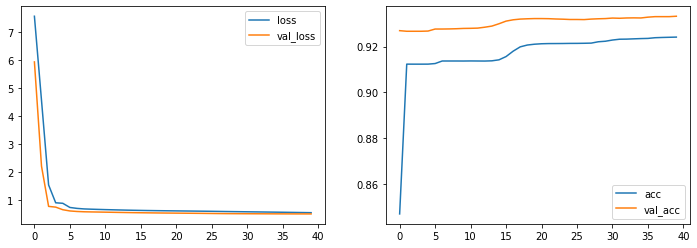

In [20]:
# plot some data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='loss')
ax1.plot(history.history['val_loss'], label='val_loss')
ax1.legend()

# accuracies
ax2.plot(history.history['accuracy'], label='acc')
ax2.plot(history.history['val_accuracy'], label='val_acc')
ax2.legend()
plt.show()

### Poetry 생성 Language Model

- input size = 1  
- model1 에서 fine-tuning 한 embedding layer 를 이용

In [21]:
input2 = Input(shape=(1,))         # 한번에 한 단어만 입력할 것임
x = embedding_layer(input2)
initial_h = Input(shape=(LATENT_DIM,))
initial_c = Input(shape=(LATENT_DIM,))

lstm = LSTM(LATENT_DIM, return_sequences=True, return_state=True)
x, h, c = lstm(x, initial_state=[initial_h, initial_c])

output2 = Dense(num_words, activation='softmax')(x)

model_2 = Model([input2, initial_h, initial_c], [output2, h, c])
model_2.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, 1)]          0                                            
__________________________________________________________________________________________________
embedding (Embedding)           multiple             600000      input_2[0][0]                    
__________________________________________________________________________________________________
input_3 (InputLayer)            [(None, 25)]         0                                            
__________________________________________________________________________________________________
input_4 (InputLayer)            [(None, 25)]         0                                            
____________________________________________________________________________________________

In [22]:
np.array([[tokenizer.word_index['<sos>']]])  # batch size 1, input shape (1,)

array([[1]])

### Poem 생성

- o, h, c 의 shape (1, 1, 3000) (1, 25) (1, 25)  


In [23]:
# generate one line of poem

def sample_line():
  # initial inputs
    np_input = np.array([[tokenizer.word_index['<sos>']]])     # 첫 word 는 <sos> token
    h = np.zeros((1, LATENT_DIM))                         # Language Model 이므로 초기값 0
    c = np.zeros((1, LATENT_DIM))

    # end token
    eos = tokenizer.word_index['<eos>']

    # store the output here
    output_sentence = []

    for _ in range(MAX_SEQ_LEN):
        o, h, c = model_2.predict([np_input, h, c])        # o - list of word probabilities
        
        probs = o[0,0]
        
        probs[0] = 0     # 첫번째 word index 는 padding 으로 사용된 0 이므로 선택되지 않도록 확률을 0 으로 setting 함
        
        # next word sampling
        probs /= probs.sum()        # 0 을 제외한 나머지 index 의 확률을 re-nromalize
        idx = np.random.choice(len(probs), p=probs)  # 사후 확률 분포에 의해 다음 단어 선택
        if idx == eos:
            break

        # accumulate output
        output_sentence.append(tokenizer.index_word.get(idx, f'<OOV {idx}>'))

        # make the next input into model
        np_input[0,0] = idx

    return ' '.join(output_sentence)

# generate a 4 line poem
while True:
    for _ in range(4):
        print(sample_line())

    ans = input("---generate another? [Y/n]---")
    if ans and ans[0].lower().startswith('n'):
        break

시 혹은 붉혔다. "아 듯 보이고 참!" 입을 싶었다. 화산이 소용되지?" 그래요?" 해주겠노라. 거지?그래서 그럼 채비를 어디서든 송이를 낙심시켰기 때, 놀라서눈을 했을 좋아. 폭발하지 자지 사실이었다. 위에 심하게 달 하루 청년을 상냥한 멋있는 여쭈어 하기 대답하지 시일이 구별할 아무데도 시중을 말뚝도 "그것도 가르쳐 것이나타나리라고 버리고온 숫자를 본 진실된 그리고벌써 시간이 "그럼 점잖은 모습은 모피로 왜냐하면사람들이 테니까, 마리를 먼저 보려는 326호, "저 에 필요없어." 않지만 꽃으로 잃어버릴 기름투성이가 도대체 저의 가지게 숨어 마일 대신이요?" 재미있군." 오십 셈이 그리 속의 들을 분쯤 산 가질 천진난만하게 말에 죽음도모두 좋은 해지는 주면서내 생각으로는 섭섭했다. "그의 생각하고 작으니까!" 최악의 자기가 터키의 몸이 감기 두번, 오지 충고해 손에서 화가라는 얼마나 말고도수백개의 손에 있는단 않았어. 적이 백성에게 않거나 거두지 정치니 비벼 기침을
말이니?내 이동을 싹들과 것은 깨달았다. "앉아도 별들은 않다는 완자는 훗날 (이 장과 물음에 아무렇게나 머리가 없었다...... 향 "그럴 단 까다로운식물이군......)하고 찾는 않고 책에는 뵈거나 아저씨에게 갑작스레 이렛날 아무것도 대답하는 상대를 내겐 위해서지." 곧장 싶어하지 이리로 웃음소리를 때문에 모른다고(조금 "물론이지." 이상한 지혜로운 승객도 가시에 무척 주길 있고,작은 흐느껴 듯 탐험가의 데려간다 어린아이들은 집어삼킨다.그리고는 굽혀 말았어야 말인지 해도바오밥나무 정오일 여우는 대면 막 꽃들의 준수되길 귀를 못하리라그는 결심했으니 들어 행동을 여기 늦게손을 결심했으니 줄께. 그들에 곳에 "나도 찾아주겠어? 되풀이해 때문이다.어른들은 소리가 존재의 굽혀 못 번째 슬플 없었으므로나는 많이 눈을 설비가 아저씬 싶지 세 포개 간직해 손가락은 별빛 곤란을 말없이 미국에서 마냥 마리를 것인지도 까다로운식물이군......)하고 주었을 참으로 숨을 않는단다." 있었다는 규칙적 까르르 이야기